# Phase 0 EDA
Aggregates and plots only. No raw rows are displayed (dataset is not redistributable).

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data import load_raw
df = load_raw()   # prints memory before -> after
print('shape:', df.shape)
print('fraud rate: %.4f' % df.isFraud.mean(), '| fraud count:', int(df.isFraud.sum()))

memory: 2081 MB -> 977 MB
shape: (590540, 434)
fraud rate: 0.0350 | fraud count: 20663


## Time
`TransactionDT` is seconds from an unknown reference, not a date.

In [2]:
dt = df.TransactionDT
print('min %d  max %d  span %.1f days' % (dt.min(), dt.max(), (dt.max()-dt.min())/86400))
print('unique TransactionID:', df.TransactionID.is_unique)

min 86400  max 15811131  span 182.0 days
unique TransactionID: True


## Missing values (share of columns by % missing)

In [3]:
miss = df.isna().mean()*100
print(pd.cut(miss, [-0.01,0,10,50,90,100]).value_counts().sort_index().to_string())
print('\nworst 10 columns by % missing:'); print(miss.sort_values(ascending=False).head(10).round(1).to_string())

(-0.01, 0.0]      20
(0.0, 10.0]       92
(10.0, 50.0]     108
(50.0, 90.0]     202
(90.0, 100.0]     12

worst 10 columns by % missing:
id_24    99.2
id_25    99.1
id_07    99.1
id_08    99.1
id_21    99.1
id_26    99.1
id_27    99.1
id_23    99.1
id_22    99.1
dist2    93.6


## Identity data

In [4]:
has_id = df['DeviceType'].notna() | df['id_01'].notna()
g = df.groupby(has_id).isFraud.agg(['size','mean'])
g.index = ['no identity','has identity']; print(g.rename(columns={'size':'rows','mean':'fraud_rate'}).to_string())

                rows  fraud_rate
no identity   446307    0.020939
has identity  144233    0.078470


## TransactionAmt

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


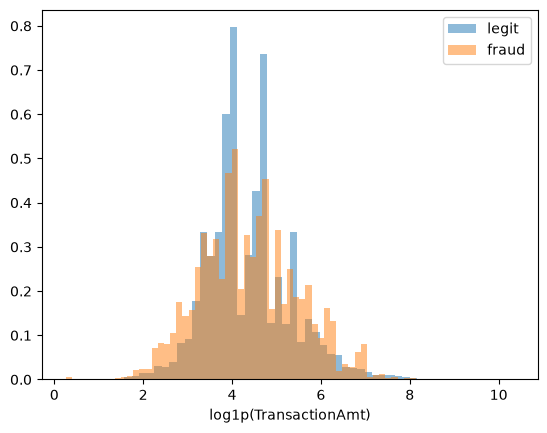

In [5]:
print(df.groupby('isFraud').TransactionAmt.describe().round(2).to_string())
fig, ax = plt.subplots()
for k, lab in [(0,'legit'),(1,'fraud')]:
    ax.hist(np.log1p(df.loc[df.isFraud==k,'TransactionAmt']), bins=60, alpha=.5, density=True, label=lab)
ax.set_xlabel('log1p(TransactionAmt)'); ax.legend(); plt.show()

## Fraud rate over time (weekly buckets) - first look at drift

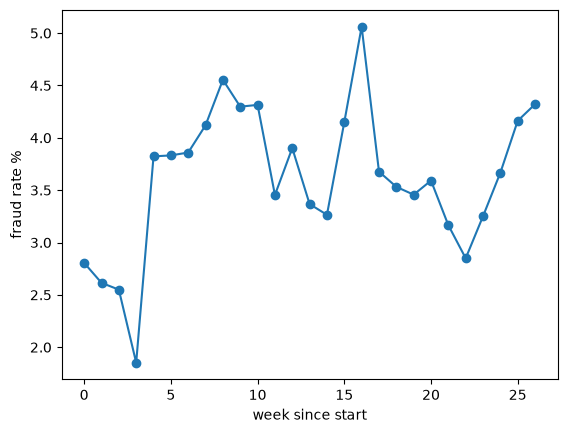

                rows  fraud_rate
TransactionDT                   
0              23810      0.0281
1              27803      0.0261
2              34470      0.0255
3              37251      0.0185
4              24041      0.0382
5              21868      0.0383
6              20392      0.0386
7              20025      0.0412
8              20246      0.0455
9              23596      0.0430
10             20860      0.0431
11             19831      0.0345
12             21734      0.0390
13             27770      0.0337
14             21901      0.0326
15             20700      0.0415
16             21003      0.0506
17             23824      0.0368
18             19622      0.0353
19             18630      0.0346
20             18460      0.0359
21             20378      0.0317
22             20740      0.0285
23             20944      0.0325
24             20206      0.0367
25             17681      0.0416
26              2754      0.0432


In [6]:
wk = (df.TransactionDT // (7*86400))
r = df.groupby(wk).isFraud.agg(['size','mean'])
fig, ax = plt.subplots(); ax.plot(r.index, r['mean']*100, marker='o')
ax.set_xlabel('week since start'); ax.set_ylabel('fraud rate %'); plt.show()
print(r.rename(columns={'size':'rows','mean':'fraud_rate'}).round(4).to_string())